In [4]:
import os

print(os.getcwd())
print(os.listdir())

/content
['.config', 'loan_default_dataset.csv', 'sample_data']


Dataset loaded successfully!
Shape: (5000, 10)

Columns:
['Income', 'CreditScore', 'LoanAmount', 'InterestRate', 'DTI', 'EmploymentStatus', 'LoanTerm', 'LoanPurpose', 'HomeOwnership', 'Default']

First 5 rows:
   Income  CreditScore  LoanAmount  InterestRate    DTI EmploymentStatus  \
0   52449          608       16851          9.49  26.46        Full-time   
1   25034          469       37353          6.81   8.23       Unemployed   
2   67020          358       23288          7.53  36.36        Part-time   
3   74407          537        6218          8.27  23.12    Self-employed   
4   15168          443       34205         11.04  26.36       Unemployed   

   LoanTerm LoanPurpose HomeOwnership  Default  
0        60    Personal          Rent        1  
1        60        Auto           Own        0  
2        60    Personal          Rent        1  
3        60        Auto      Mortgage        1  
4        36    Business          Rent        1  

Missing values:
Income              0


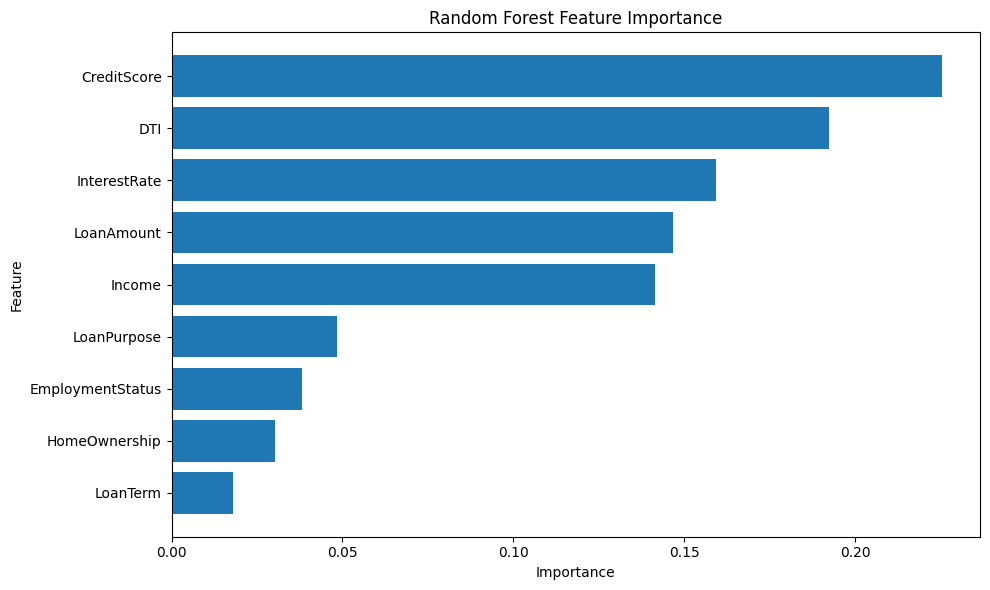

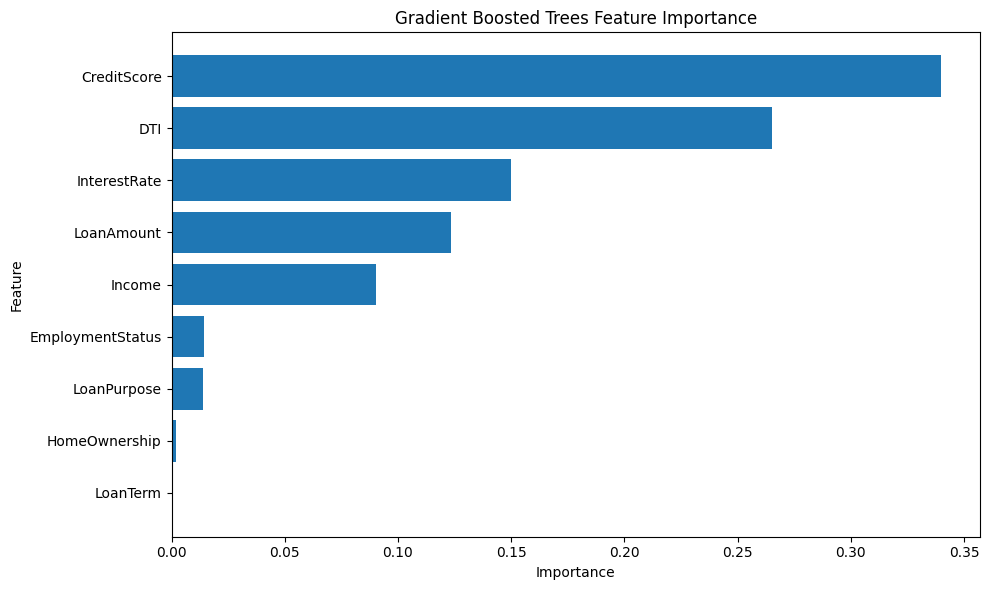

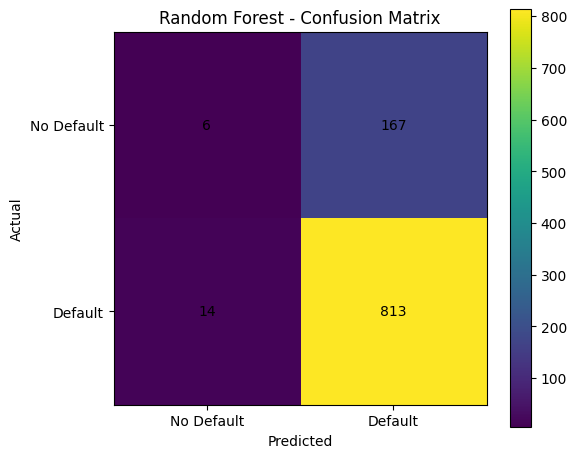

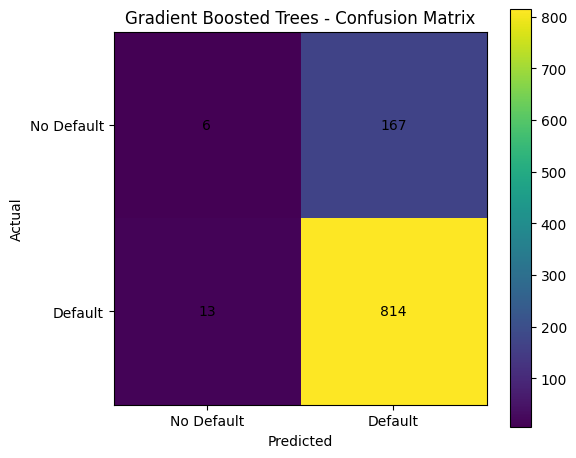


Results saved successfully!
1. model_comparison_results.csv
2. feature_importance_results.csv


In [5]:
# ============================================================
# LOAN DEFAULT PREDICTION
# Random Forest + Gradient Boosting
# Dataset: loan_default_dataset.csv
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# ============================================================
# 1. LOAD DATASET
# ============================================================

DATA_PATH = "loan_default_dataset.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
print(df.head())


# ============================================================
# 2. CHECK DATA
# ============================================================

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nDefault distribution:")
print(df["Default"].value_counts())


# ============================================================
# 3. HANDLE CATEGORICAL DATA
# ============================================================

# Make a copy
data = df.copy()

# Find categorical columns
categorical_columns = data.select_dtypes(
    include=["object"]
).columns

print("\nCategorical columns:")
print(categorical_columns.tolist())

# Convert categorical columns to numbers
for column in categorical_columns:
    encoder = LabelEncoder()
    data[column] = encoder.fit_transform(
        data[column].astype(str)
    )


# ============================================================
# 4. SEPARATE FEATURES AND TARGET
# ============================================================

X = data.drop("Default", axis=1)
y = data["Default"]

print("\nFeatures:")
print(X.columns.tolist())

print("\nX shape:", X.shape)
print("y shape:", y.shape)


# ============================================================
# 5. TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))


# ============================================================
# 6. RANDOM FOREST
# ============================================================

print("\n")
print("=" * 60)
print("TRAINING RANDOM FOREST")
print("=" * 60)

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_prob = rf_model.predict_proba(X_test)[:, 1]


# ============================================================
# 7. RANDOM FOREST RESULTS
# ============================================================

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(
    y_test, rf_pred, zero_division=0
)
rf_recall = recall_score(
    y_test, rf_pred, zero_division=0
)
rf_f1 = f1_score(
    y_test, rf_pred, zero_division=0
)
rf_auc = roc_auc_score(y_test, rf_prob)

print("\nRANDOM FOREST RESULTS")
print("-" * 40)

print("Accuracy :", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall   :", round(rf_recall, 4))
print("F1 Score :", round(rf_f1, 4))
print("ROC-AUC  :", round(rf_auc, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        rf_pred,
        zero_division=0
    )
)

print("Confusion Matrix:")
print(confusion_matrix(y_test, rf_pred))


# ============================================================
# 8. GRADIENT BOOSTING
# ============================================================

print("\n")
print("=" * 60)
print("TRAINING GRADIENT BOOSTED TREES")
print("=" * 60)

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

gb_prob = gb_model.predict_proba(X_test)[:, 1]


# ============================================================
# 9. GRADIENT BOOSTING RESULTS
# ============================================================

gb_accuracy = accuracy_score(y_test, gb_pred)
gb_precision = precision_score(
    y_test, gb_pred, zero_division=0
)
gb_recall = recall_score(
    y_test, gb_pred, zero_division=0
)
gb_f1 = f1_score(
    y_test, gb_pred, zero_division=0
)
gb_auc = roc_auc_score(y_test, gb_prob)

print("\nGRADIENT BOOSTED TREES RESULTS")
print("-" * 40)

print("Accuracy :", round(gb_accuracy, 4))
print("Precision:", round(gb_precision, 4))
print("Recall   :", round(gb_recall, 4))
print("F1 Score :", round(gb_f1, 4))
print("ROC-AUC  :", round(gb_auc, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        gb_pred,
        zero_division=0
    )
)

print("Confusion Matrix:")
print(confusion_matrix(y_test, gb_pred))


# ============================================================
# 10. MODEL COMPARISON
# ============================================================

results = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Gradient Boosted Trees"
    ],
    "Accuracy": [
        rf_accuracy,
        gb_accuracy
    ],
    "Precision": [
        rf_precision,
        gb_precision
    ],
    "Recall": [
        rf_recall,
        gb_recall
    ],
    "F1 Score": [
        rf_f1,
        gb_f1
    ],
    "ROC-AUC": [
        rf_auc,
        gb_auc
    ]
})

print("\n")
print("=" * 60)
print("MODEL COMPARISON")
print("=" * 60)

print(results.round(4).to_string(index=False))


# ============================================================
# 11. FEATURE IMPORTANCE
# ============================================================

importance = pd.DataFrame({
    "Feature": X.columns,
    "Random Forest": rf_model.feature_importances_,
    "Gradient Boosting": gb_model.feature_importances_
})

importance = importance.sort_values(
    "Random Forest",
    ascending=False
)

print("\n")
print("=" * 60)
print("FEATURE IMPORTANCE")
print("=" * 60)

print(importance.to_string(index=False))


# ============================================================
# 12. RANDOM FOREST FEATURE IMPORTANCE GRAPH
# ============================================================

plt.figure(figsize=(10, 6))

rf_importance = importance.sort_values(
    "Random Forest"
)

plt.barh(
    rf_importance["Feature"],
    rf_importance["Random Forest"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.tight_layout()
plt.show()


# ============================================================
# 13. GRADIENT BOOSTING FEATURE IMPORTANCE GRAPH
# ============================================================

plt.figure(figsize=(10, 6))

gb_importance = importance.sort_values(
    "Gradient Boosting"
)

plt.barh(
    gb_importance["Feature"],
    gb_importance["Gradient Boosting"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Gradient Boosted Trees Feature Importance")

plt.tight_layout()
plt.show()


# ============================================================
# 14. CONFUSION MATRIX - RANDOM FOREST
# ============================================================

cm_rf = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6, 5))

plt.imshow(cm_rf)

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([0, 1], ["No Default", "Default"])
plt.yticks([0, 1], ["No Default", "Default"])

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm_rf[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()
plt.show()


# ============================================================
# 15. CONFUSION MATRIX - GRADIENT BOOSTING
# ============================================================

cm_gb = confusion_matrix(y_test, gb_pred)

plt.figure(figsize=(6, 5))

plt.imshow(cm_gb)

plt.title("Gradient Boosted Trees - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([0, 1], ["No Default", "Default"])
plt.yticks([0, 1], ["No Default", "Default"])

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm_gb[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()
plt.show()


# ============================================================
# 16. SAVE RESULTS
# ============================================================

results.to_csv(
    "model_comparison_results.csv",
    index=False
)

importance.to_csv(
    "feature_importance_results.csv",
    index=False
)

print("\nResults saved successfully!")
print("1. model_comparison_results.csv")
print("2. feature_importance_results.csv")